<a href="https://colab.research.google.com/github/corebankingfiap-dev/core_banking/blob/main/04_02_Heatmap_Correlacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vermelho Forte: Correlação Alta (Perigo de concentração).

Azul/Branco: Correlação Baixa ou Negativa (Proteção).

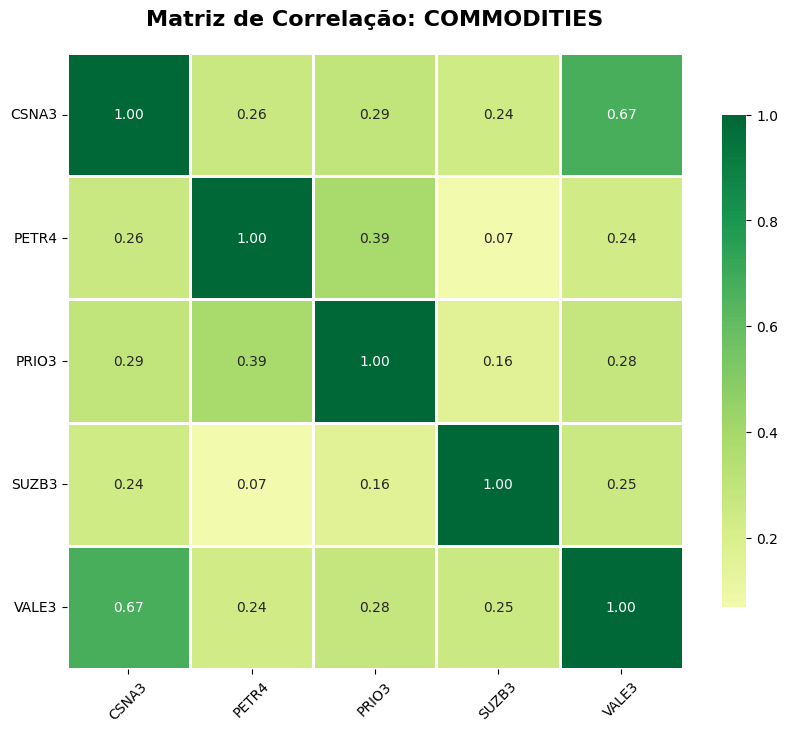

✅ Heatmap de COMMODITIES gerado e salvo na pasta REPORTS!


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Montar o Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. CONFIGURAÇÃO (Sincronizado com suas pastas)
SEGMENTO = "commodities" # Use letras minúsculas como na sua pasta do Drive
PATH_REPORTS = f'/content/drive/MyDrive/DATA_LAKE/03_Gold/REPORTS/'

# 3. LEITURA DO CSV (Ajustado de Parquet para CSV conforme sua Gold)
file_path = os.path.join(PATH_REPORTS, f"CORREL_{SEGMENTO.upper()}.csv")

if os.path.exists(file_path):
    # Lemos o CSV garantindo que a primeira coluna seja o índice (os nomes dos ativos)
    df_corr = pd.read_csv(file_path, index_col=0)

    # 4. CRIAÇÃO DO GRÁFICO (Visual Profissional)
    plt.figure(figsize=(10, 8))

    # cmap='RdYlGn' mostra Verde (positivo), Amarelo (neutro) e Vermelho (negativo)
    sns.heatmap(df_corr,
                annot=True,
                fmt=".2f",
                cmap='RdYlGn',
                center=0,
                linewidths=1,
                square=True,
                cbar_kws={"shrink": .8})

    plt.title(f'Matriz de Correlação: {SEGMENTO.upper()}', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    # 5. SALVAMENTO DA IMAGEM
    plt.savefig(os.path.join(PATH_REPORTS, f"HEATMAP_{SEGMENTO.upper()}.png"), bbox_inches='tight')
    plt.show()

    print(f"✅ Heatmap de {SEGMENTO.upper()} gerado e salvo na pasta REPORTS!")
else:
    print(f"❌ Arquivo não encontrado: {file_path}")
    print("Dica: Rode o código de Correlação primeiro para gerar o arquivo CSV.")